In [163]:
import pandas as pd, sqlite3
connection = sqlite3.connect("../../data/checking-logs.sqlite")

In [164]:
query = '''
WITH pre_res AS (
SELECT
    DATE(timestamp) AS date,
    CAST(STRFTIME('%H', timestamp) AS INT) AS hour,
    CAST(STRFTIME('%w', timestamp) AS INT) AS weekday,
    COUNT(*) AS commits
FROM checker
WHERE uid LIKE 'user%'
GROUP BY
    date,
    hour
ORDER BY
    date,
    hour)
SELECT hour, commits  FROM pre_res
WHERE weekday IN (0,6);
'''
weekend = pd.read_sql(query, connection)

In [165]:
query = '''
WITH pre_res AS (
SELECT
    DATE(timestamp) AS date,
    CAST(STRFTIME('%H', timestamp) AS INT) AS hour,
    CAST(STRFTIME('%w', timestamp) AS INT) AS weekday,
    COUNT(*) AS commits
FROM checker
WHERE uid LIKE 'user%'
GROUP BY
    date,
    hour
ORDER BY
    date,
    hour)
SELECT hour, commits  FROM pre_res
WHERE weekday IN (1,2,3,4,5);
'''
workdays = pd.read_sql(query, connection)



In [166]:
avg_workdays = workdays.groupby('hour')['commits'].mean()
avg_weekend = weekend.groupby('hour')['commits'].mean()

avg_workdays = avg_workdays.reindex(range(24), fill_value=0)
avg_weekend = avg_weekend.reindex(range(24), fill_value=0)

In [167]:
avg_weekend

hour
0      2.000000
1      6.000000
2      0.000000
3      1.000000
4      0.000000
5      2.000000
6      0.000000
7      4.000000
8      7.000000
9      3.666667
10     7.000000
11    23.600000
12     9.500000
13    18.000000
14    12.428571
15    14.250000
16    14.800000
17     7.142857
18     9.714286
19    13.125000
20    13.000000
21    10.285714
22     9.833333
23     6.400000
Name: commits, dtype: float64

In [168]:
avg_workdays

hour
0      3.000000
1      0.000000
2      0.000000
3      2.000000
4      0.000000
5      7.500000
6      1.500000
7      5.166667
8      3.700000
9      6.000000
10    13.200000
11     6.769231
12     7.181818
13     8.111111
14    10.166667
15    12.818182
16    18.888889
17    16.000000
18    15.181818
19    17.833333
20    14.076923
21    24.333333
22     3.750000
23     5.000000
Name: commits, dtype: float64

In [169]:
big_df = pd.DataFrame({'weekend': avg_weekend, 'working_day': avg_workdays}).fillna(0)

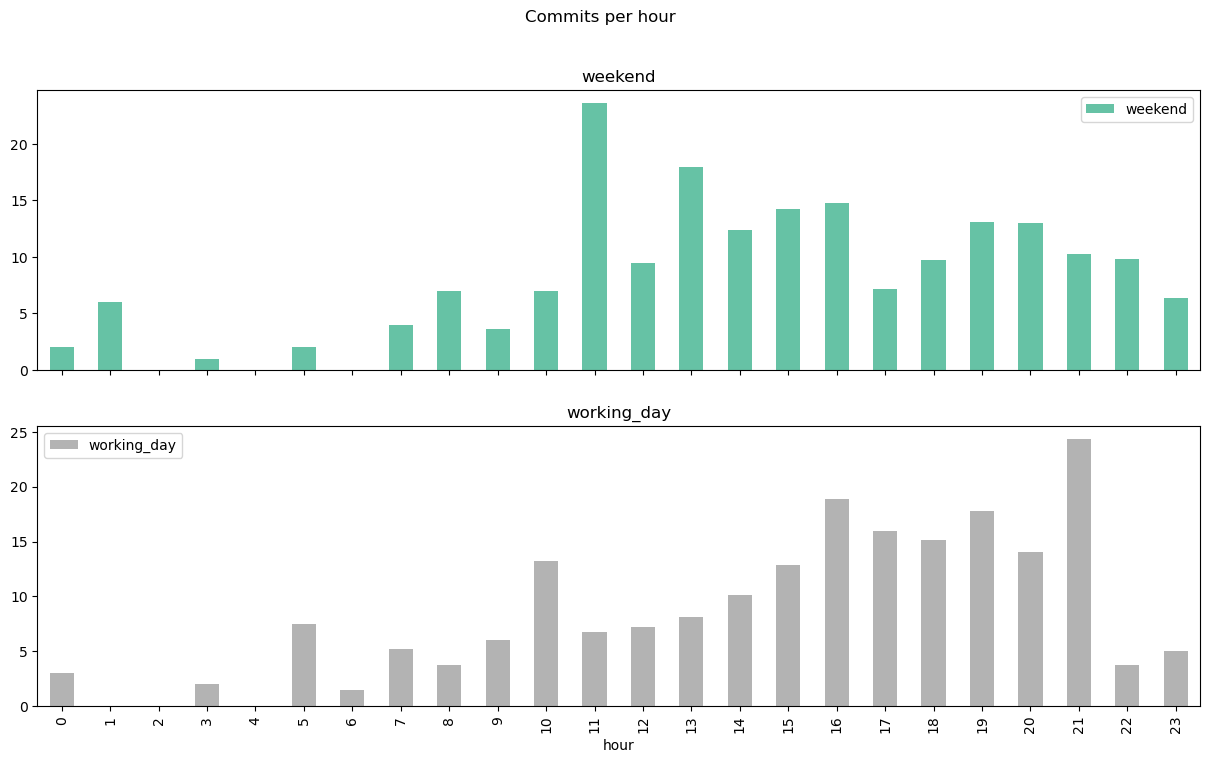

In [170]:
big_df.plot(
    kind='bar',
    subplots=True,
    layout=(2, 1),
    figsize=(15, 8),
    sharex=True,
    legend=True,
    colormap='Set2', 
    title='Commits per hour',
);

## Is the dynamic different on working days and weekends?

In [171]:
workdays_trend = avg_workdays.idxmax()
workdays_trend

21

In [172]:
weekend_trend = avg_weekend.idxmax()
weekend_trend

11

In [173]:
connection.close()